STEP 1: Load raw data

STEP 2: Clean data
[clean_data] WARNING: 2 duplicate Ticker-MthCalDt rows found. Keeping the first occurrence.
[clean_data] Rows: 1145 raw -> 1145 after dropping missing returns -> 1144 after outlier/dup filters

STEP 3: Reshape to wide return matrix (balanced panel)
[reshape_to_wide] Universe: ['AMD', 'AVGO', 'MU', 'NVDA', 'TSM', 'VOO']
[reshape_to_wide] 192 months in raw pivot -> 184 months in the common (balanced) sample, spanning 2010-09-30 to 2025-12-31

STEP 4: Estimate mean-variance inputs

Means & Std Devs (annualized):
        Ann. Mean Return  Ann. Std Dev
Ticker                                
AMD               0.3908        0.5612
AVGO              0.4107        0.3180
MU                0.3444        0.4369
NVDA              0.5444        0.4464
TSM               0.2940        0.2809
VOO               0.1478        0.1398

Correlation matrix:
Ticker    AMD   AVGO     MU   NVDA    TSM    VOO
Ticker                                          
AMD     1.00

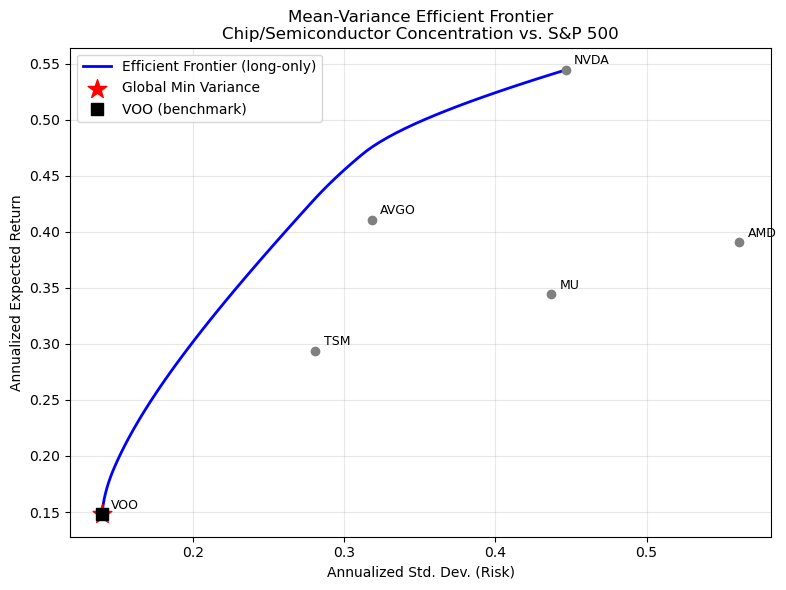

[plot_frontier] Saved plot to output_efficient_frontier.png

Done. Variables available for further use: returns_wide, mu, cov, corr, summary, frontier, gmv


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import minimize

# ----------------------------------------------------------------------
# 0. CONFIG - edit these to match your group's final decisions
# ----------------------------------------------------------------------

INPUT_FILE = "CFM_301_Project 1_Data.xlsx"   # must be in the same folder
OUTPUT_PREFIX = "output"
BENCHMARK_TICKER = "VOO"          # the broad-market comparison asset
N_FRONTIER_POINTS = 100           # resolution of the frontier
ALLOW_SHORT_SALES = False         # matches "no short sales" constraint
ANNUALIZATION_FACTOR = 12         # monthly -> annual


# ----------------------------------------------------------------------
# 1. LOAD + CLEAN
# ----------------------------------------------------------------------

def load_raw_data(path: str) -> pd.DataFrame:
    """Load the raw WRDS pull (long format) from CSV or Excel."""
    if path.lower().endswith((".xlsx", ".xls")):
        df = pd.read_excel(path)
    else:
        df = pd.read_csv(path)

    df.columns = [c.strip() for c in df.columns]
    rename_map = {c: c for c in df.columns}
    canonical = {
        "permno": "PERMNO", "hdrcusip": "HdrCUSIP", "ticker": "Ticker",
        "permco": "PERMCO", "mthcaldt": "MthCalDt", "mthprc": "MthPrc",
        "mthprcdt": "MthPrcDt", "mthret": "MthRet", "mthretx": "MthRetx",
    }
    for c in df.columns:
        key = c.lower().replace("_", "").replace(" ", "")
        if key in canonical:
            rename_map[c] = canonical[key]
    df = df.rename(columns=rename_map)

    required = {"Ticker", "MthCalDt", "MthRet"}
    missing = required - set(df.columns)
    if missing:
        raise ValueError(f"Input file is missing required columns: {missing}")

    return df


def clean_data(df: pd.DataFrame) -> pd.DataFrame:
    """
    Cleaning steps (document these in the report's Data section):
      - parse dates
      - drop rows with missing/NaN returns
      - drop rows where |MthRet| > 100% in a single month (likely a bad
        print or corporate-action artifact) - inspect these before
        trusting the filter blindly
      - drop exact duplicate Ticker-MthCalDt rows, keeping the first
    """
    df = df.copy()
    df["MthCalDt"] = pd.to_datetime(df["MthCalDt"])
    df["MthRet"] = pd.to_numeric(df["MthRet"], errors="coerce")

    n_before = len(df)
    df = df.dropna(subset=["MthRet"])
    n_after_na = len(df)

    outlier_mask = df["MthRet"].abs() > 1.0
    n_outliers = outlier_mask.sum()
    if n_outliers > 0:
        print(f"[clean_data] WARNING: dropping {n_outliers} rows with "
              f"|MthRet| > 100% -- inspect these manually:")
        print(df.loc[outlier_mask, ["Ticker", "MthCalDt", "MthRet"]])
    df = df.loc[~outlier_mask]

    dupes = df.duplicated(subset=["Ticker", "MthCalDt"], keep=False)
    if dupes.any():
        print(f"[clean_data] WARNING: {dupes.sum()} duplicate "
              f"Ticker-MthCalDt rows found. Keeping the first occurrence.")
        df = df.drop_duplicates(subset=["Ticker", "MthCalDt"], keep="first")

    print(f"[clean_data] Rows: {n_before} raw -> {n_after_na} after "
          f"dropping missing returns -> {len(df)} after outlier/dup filters")

    return df


def reshape_to_wide(df: pd.DataFrame) -> pd.DataFrame:
    """
    Pivot long -> wide: index = month-end date, columns = Ticker,
    values = MthRet. Then restrict to months where EVERY ticker has a
    return (balanced panel), which is required for valid covariance
    estimates across assets.
    """
    wide = df.pivot_table(index="MthCalDt", columns="Ticker",
                           values="MthRet", aggfunc="first")
    wide = wide.sort_index()

    n_rows_before = len(wide)
    wide_common = wide.dropna(how="any")
    n_rows_after = len(wide_common)

    print(f"[reshape_to_wide] Universe: {list(wide.columns)}")
    print(f"[reshape_to_wide] {n_rows_before} months in raw pivot -> "
          f"{n_rows_after} months in the common (balanced) sample, "
          f"spanning {wide_common.index.min().date()} to "
          f"{wide_common.index.max().date()}")

    if n_rows_after < 24:
        print("[reshape_to_wide] WARNING: fewer than 24 months of common "
              "data - covariance estimates will be noisy.")

    return wide_common


# ----------------------------------------------------------------------
# 2. MEAN-VARIANCE INPUTS
# ----------------------------------------------------------------------

def estimate_inputs(returns_wide: pd.DataFrame):
    """
    Sample mean/covariance on monthly returns, annualized:
      mean: monthly_mean * 12
      cov:  monthly_cov  * 12
      std:  sqrt(diag(annualized cov))
      corr: scale-free, unaffected by annualization
    """
    mu_monthly = returns_wide.mean()
    cov_monthly = returns_wide.cov()

    mu_annual = mu_monthly * ANNUALIZATION_FACTOR
    cov_annual = cov_monthly * ANNUALIZATION_FACTOR
    std_annual = pd.Series(np.sqrt(np.diag(cov_annual)), index=cov_annual.index)
    corr = returns_wide.corr()

    summary = pd.DataFrame({
        "Ann. Mean Return": mu_annual,
        "Ann. Std Dev": std_annual,
    })

    return mu_annual, cov_annual, corr, summary


# ----------------------------------------------------------------------
# 3. EFFICIENT FRONTIER (long-only, no risk-free asset)
# ----------------------------------------------------------------------

def portfolio_variance(w, cov):
    return w @ cov @ w


def min_variance_for_target_return(mu, cov, target_return, allow_short):
    n = len(mu)
    w0 = np.ones(n) / n

    constraints = [
        {"type": "eq", "fun": lambda w: np.sum(w) - 1.0},
        {"type": "eq", "fun": lambda w: w @ mu.values - target_return},
    ]
    bounds = None if allow_short else [(0.0, 1.0)] * n

    result = minimize(
        portfolio_variance, w0, args=(cov.values,),
        method="SLSQP", bounds=bounds, constraints=constraints,
        options={"maxiter": 1000, "ftol": 1e-12},
    )
    if not result.success:
        return None
    return result.x


def trace_efficient_frontier(mu, cov, n_points=N_FRONTIER_POINTS,
                              allow_short=ALLOW_SHORT_SALES):
    target_returns = np.linspace(mu.min(), mu.max(), n_points)

    rows = []
    for tr in target_returns:
        w = min_variance_for_target_return(mu, cov, tr, allow_short)
        if w is None:
            continue
        achieved_ret = w @ mu.values
        achieved_std = np.sqrt(portfolio_variance(w, cov.values))
        rows.append([achieved_ret, achieved_std] + list(w))

    cols = ["Return", "StdDev"] + list(mu.index)
    frontier = pd.DataFrame(rows, columns=cols)

    gmv_idx = frontier["StdDev"].idxmin()
    gmv = frontier.loc[gmv_idx]

    return frontier, gmv


# ----------------------------------------------------------------------
# 4. PLOT
# ----------------------------------------------------------------------

def plot_frontier(frontier, mu, std, gmv, benchmark_ticker,
                   out_path="efficient_frontier.png"):
    fig, ax = plt.subplots(figsize=(8, 6))

    ax.plot(frontier["StdDev"], frontier["Return"], "b-", lw=2,
            label="Efficient Frontier (long-only)")

    ax.scatter(std, mu, color="gray", zorder=5)
    for ticker in mu.index:
        ax.annotate(ticker, (std[ticker], mu[ticker]),
                     textcoords="offset points", xytext=(6, 4), fontsize=9)

    ax.scatter(gmv["StdDev"], gmv["Return"], color="red", marker="*",
               s=200, zorder=6, label="Global Min Variance")

    if benchmark_ticker in mu.index:
        ax.scatter(std[benchmark_ticker], mu[benchmark_ticker],
                   color="black", marker="s", s=80, zorder=6,
                   label=f"{benchmark_ticker} (benchmark)")

    ax.set_xlabel("Annualized Std. Dev. (Risk)")
    ax.set_ylabel("Annualized Expected Return")
    ax.set_title("Mean-Variance Efficient Frontier\n"
                 "Chip/Semiconductor Concentration vs. S&P 500")
    ax.legend()
    ax.grid(alpha=0.3)
    fig.tight_layout()
    fig.savefig(out_path, dpi=150)
    plt.show()
    print(f"[plot_frontier] Saved plot to {out_path}")


# ----------------------------------------------------------------------
# RUN EVERYTHING (just executes top to bottom - no main(), no argparse)
# ----------------------------------------------------------------------

print("=" * 70)
print("STEP 1: Load raw data")
df_raw = load_raw_data(INPUT_FILE)

print("\n" + "=" * 70)
print("STEP 2: Clean data")
df_clean = clean_data(df_raw)

print("\n" + "=" * 70)
print("STEP 3: Reshape to wide return matrix (balanced panel)")
returns_wide = reshape_to_wide(df_clean)
returns_wide.to_csv(f"{OUTPUT_PREFIX}_returns_wide.csv")

print("\n" + "=" * 70)
print("STEP 4: Estimate mean-variance inputs")
mu, cov, corr, summary = estimate_inputs(returns_wide)
std = summary["Ann. Std Dev"]

print("\nMeans & Std Devs (annualized):")
print(summary.round(4))
print("\nCorrelation matrix:")
print(corr.round(3))

summary.round(4).to_csv(f"{OUTPUT_PREFIX}_mean_std_table.csv")
corr.round(3).to_csv(f"{OUTPUT_PREFIX}_correlation_matrix.csv")
cov.round(6).to_csv(f"{OUTPUT_PREFIX}_covariance_matrix.csv")

print("\n" + "=" * 70)
print("STEP 5: Trace efficient frontier")
frontier, gmv = trace_efficient_frontier(mu, cov)
frontier.round(4).to_csv(f"{OUTPUT_PREFIX}_frontier_points.csv", index=False)

print("\nGlobal Min Variance portfolio:")
print(gmv.round(4))

print("\n" + "=" * 70)
print("STEP 6: Plot frontier")
plot_frontier(frontier, mu, std, gmv, BENCHMARK_TICKER,
              out_path=f"{OUTPUT_PREFIX}_efficient_frontier.png")

print("\nDone. Variables available for further use: returns_wide, mu, cov, "
      "corr, summary, frontier, gmv")

In [12]:
import os; print(os.getcwd())

/Users/nehasrinivasan/CFM301


In [3]:
import sys; print(sys.executable) 



/Users/nehasrinivasan/anaconda3/envs/CFM101/bin/python
